In [1]:
import os
import h5py
import pandas as pd
from torch.utils.data import Dataset

class H5EEGDataset(Dataset):
    ## HDF5 dataset with LaBraM and Welch features
    ## Expects a directory with: pyarrow index + h5 shards
    ## Index columns: eeg_id, shard, row
    ## Expects each shard to have datasets: LaBraM, Welch, ids
    def __init__(self, root="h5_eeg_feats", ids=None, return_id=False):
        self.root = root
        df = pd.read_parquet(os.path.join(root, "index.parquet"))
        if ids is not None:
            df = df[df["eeg_id"].isin(set(ids))].reset_index(drop=True)
        self.index = df
        self.return_id = return_id
        self._files = {}  # cache: shard -> h5py.File
    
    def get_by_id(self, eeg_id):
        row = self.index[self.index["eeg_id"] == eeg_id]
        if len(row) == 0:
            raise KeyError(f"EEG ID {eeg_id} not found in index")
        if len(row) > 1:
            raise KeyError(f"EEG ID {eeg_id} found multiple times in index")
        row = row.iloc[0]
        f = self._open(row.shard)
        r = int(row.row)
        x_lbr   = f["LaBraM"][r]   # (T1, F1)
        x_welch = f["Welch"][r]    # (T2, F2)
        if self.return_id:
            return x_lbr, x_welch, row.eeg_id
        return x_lbr, x_welch

    def __len__(self):
        return len(self.index)

    def _open(self, shard):
        f = self._files.get(shard)
        if f is None:
            f = h5py.File(os.path.join(self.root, shard), "r")
            self._files[shard] = f
        return f

    def __getitem__(self, i):
        row = self.index.iloc[i]
        f = self._open(row.shard)
        r = int(row.row)
        x_lbr   = f["LaBraM"][r]   # (T1, F1)
        x_welch = f["Welch"][r]    # (T2, F2)
        if self.return_id:
            return x_lbr, x_welch, row.eeg_id
        return x_lbr, x_welch


In [2]:
import pandas as pd
import pyarrow.parquet as pq

try:
    # Test reading with different methods
    df1 = pd.read_parquet(r"H:\EEG_features\EEG_features_labram_welch_4s\index.parquet")
    print("Pandas read successful")
    print(df1.dtypes)
    print(df1.head())
    
    # Test with pyarrow directly
    table = pq.read_table(r"H:\EEG_features\EEG_features_labram_welch_4s\index.parquet")
    print("PyArrow read successful")
    print(table.schema)
    
except Exception as e:
    print(f"Parquet file is corrupted: {e}")
    print("You need to regenerate the data")

Pandas read successful
eeg_id    object
shard     object
row        int64
dtype: object
                                 eeg_id           shard  row
0  012bf4df-2154-48a8-8a8f-98c4f65c9e96  shard_00000.h5    0
1  06382a98-4f0d-473e-9c3e-a125ac5bbf2c  shard_00000.h5    1
2  09a022b9-3c60-43d0-b7d1-1aba23423e6e  shard_00000.h5    2
3  058d0079-e778-46ff-bcdc-c0fc3f1b253f  shard_00000.h5    3
4  00282340-afbc-4c4e-8c07-4d489c3a3edd  shard_00000.h5    4
PyArrow read successful
eeg_id: string
shard: string
row: int64


In [3]:
DebugDataset = H5EEGDataset(r"H:\EEG_features\EEG_features_labram_welch_4s", return_id=True)
for i in range(5):
    lbr, welch, eid = DebugDataset[i]
    print(f"Sample {i}: ID={eid}, LaBraM shape={lbr.shape}, Welch shape={welch.shape}")

Sample 0: ID=012bf4df-2154-48a8-8a8f-98c4f65c9e96, LaBraM shape=(89, 200), Welch shape=(89, 1000)
Sample 1: ID=06382a98-4f0d-473e-9c3e-a125ac5bbf2c, LaBraM shape=(89, 200), Welch shape=(89, 1000)
Sample 2: ID=09a022b9-3c60-43d0-b7d1-1aba23423e6e, LaBraM shape=(89, 200), Welch shape=(89, 1000)
Sample 3: ID=058d0079-e778-46ff-bcdc-c0fc3f1b253f, LaBraM shape=(89, 200), Welch shape=(89, 1000)
Sample 4: ID=00282340-afbc-4c4e-8c07-4d489c3a3edd, LaBraM shape=(89, 200), Welch shape=(89, 1000)


In [12]:
lbr_2d.shape

(64, 2)

c:\Users\zzy18\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


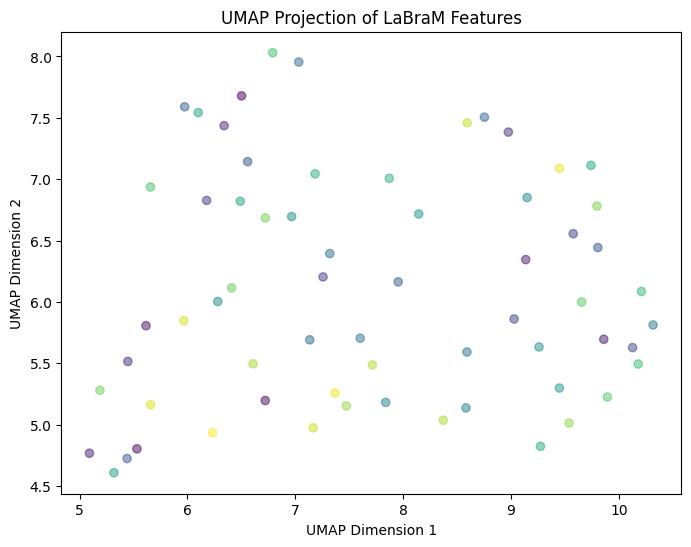

In [11]:
import umap as umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
# reduce dimensionality of LaBraM features
lbr_2d = reducer.fit_transform([DebugDataset[i][0].mean(0) for i in range(len(DebugDataset))])  # flatten the LaBraM features for UMAP input
# color coding 0-90 representing time t=0 to t=90s

colors = pd.Series(range(lbr_2d.shape[0]))  # Assuming each row corresponds to a time point
plt.figure(figsize=(8,6))
plt.scatter(lbr_2d[:,0], lbr_2d[:,1], c=colors, alpha=0.5)
plt.title("UMAP Projection of LaBraM Features")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()